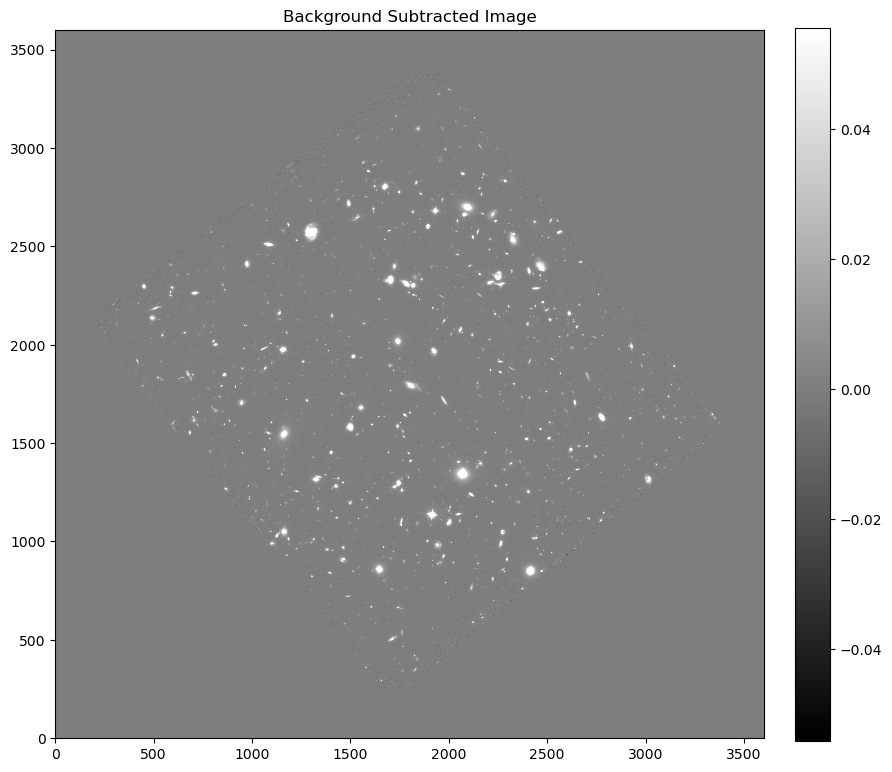

1) Sources found: 8640
2) Mean: 0.3619, Median: 0.0310, Std Dev: 9.2435
3) Largest outlier: 807.2973 (87.30 standard deviations away)


In [5]:
import numpy as np
import sep
from astropy.io import fits
import matplotlib.pyplot as plt
import os

home = os.path.expanduser("~")
file_path = os.path.join(home, "Downloads", "hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits")

# 1. Load and Fix Data
# Use the file_path variable instead of hardcoded filename
hdu = fits.open(file_path)  # Changed to use the defined file_path
data = hdu[0].data

# Fix for NumPy 2.0: Replace byteswap().newbyteorder() with the recommended approach
# This ensures proper byte ordering for SEP which expects native byte order
data = data.byteswap().view(data.dtype.newbyteorder())

# 2. Background Subtraction
bkg = sep.Background(data)
data_sub = data - bkg

# 3. Visualization (The fix for "reaching bounds")
# Setting a square figsize and origin='lower' often fixes display issues
fig, ax = plt.subplots(figsize=(10, 10))
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray', 
               vmin=m-s, vmax=m+s, origin='lower')
ax.set_title("Background Subtracted Image")
plt.colorbar(im, fraction=0.046, pad=0.04) # Adjust colorbar to match height
plt.show()

# 4. Source Extraction
objects = sep.extract(data_sub, 1.5, err=bkg.globalrms)
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'], 
                                     3.0, err=bkg.globalrms)

# --- Calculations for Final Answers ---

# Calculation 1: Source Count
num_sources = len(objects)

# Calculation 2: Distribution Statistics
f_mean = np.mean(flux)
f_med = np.median(flux)
f_std = np.std(flux)

# Calculation 3: Outlier Analysis
f_max = np.max(flux)
# Math: (74.446 - f_mean) / f_std
sigma_dist = (f_max - f_mean) / f_std

# Final Outputs
print(f"1) Sources found: {num_sources}")
print(f"2) Mean: {f_mean:.4f}, Median: {f_med:.4f}, Std Dev: {f_std:.4f}")
print(f"3) Largest outlier: {f_max:.4f} ({sigma_dist:.2f} standard deviations away)")

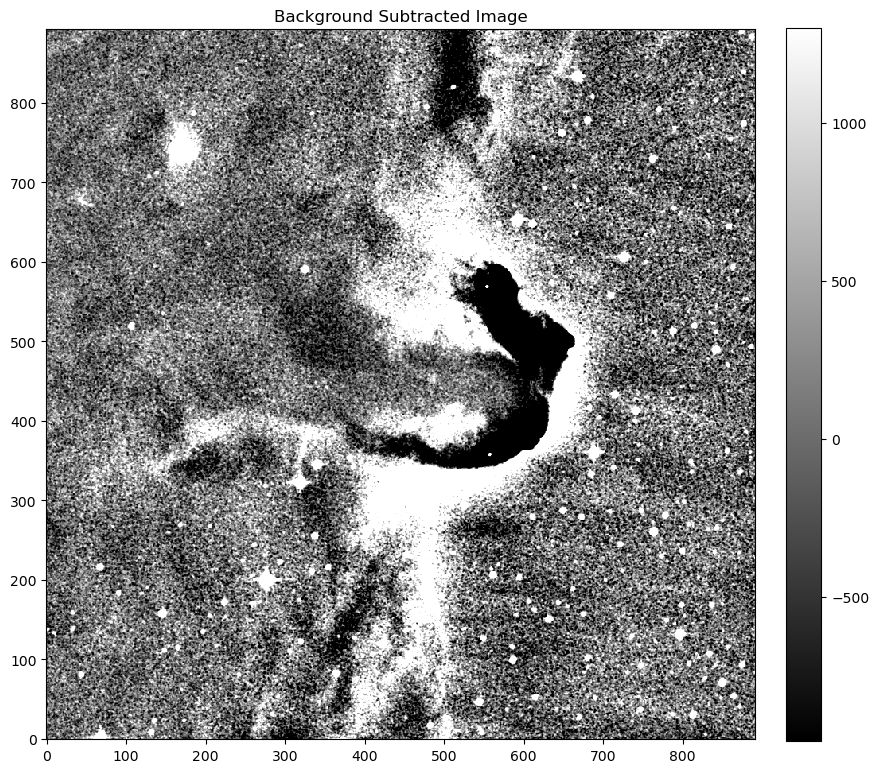

1) Sources found: 570
2) Mean: 55860.6395, Median: 30678.8199, Std Dev: 63044.9708
3) Largest outlier: 399899.1718 (5.46 standard deviations away)


In [4]:
from astropy.utils.data import get_pkg_data_filename
import numpy as np
import matplotlib.pyplot as plt
import sep
from astropy.io import fits

sample_file = get_pkg_data_filename('tutorials/FITS-images/HorseHead.fits')
hdu = fits.open(sample_file)

# Convert data to float32 which is supported by SEP
# SEP requires float32 or float64 data type
data = hdu[0].data.astype(np.float32)

# 2. Background Subtraction
bkg = sep.Background(data)
data_sub = data - bkg

# 3. Visualization (The fix for "reaching bounds")
# Setting a square figsize and origin='lower' often fixes display issues
fig, ax = plt.subplots(figsize=(10, 10))
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray', 
               vmin=m-s, vmax=m+s, origin='lower')
ax.set_title("Background Subtracted Image")
plt.colorbar(im, fraction=0.046, pad=0.04) # Adjust colorbar to match height
plt.show()

# 4. Source Extraction
objects = sep.extract(data_sub, 1.5, err=bkg.globalrms)
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'], 
                                     3.0, err=bkg.globalrms)

# --- Calculations for Final Answers ---

# Calculation 1: Source Count
num_sources = len(objects)

# Calculation 2: Distribution Statistics
f_mean = np.mean(flux)
f_med = np.median(flux)
f_std = np.std(flux)

# Calculation 3: Outlier Analysis
f_max = np.max(flux)
# Math: (74.446 - f_mean) / f_std
sigma_dist = (f_max - f_mean) / f_std

# Final Outputs
print(f"1) Sources found: {num_sources}")
print(f"2) Mean: {f_mean:.4f}, Median: {f_med:.4f}, Std Dev: {f_std:.4f}")
print(f"3) Largest outlier: {f_max:.4f} ({sigma_dist:.2f} standard deviations away)")